In [2]:
import os
os.chdir('../..')
os.getcwd()

'/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency'

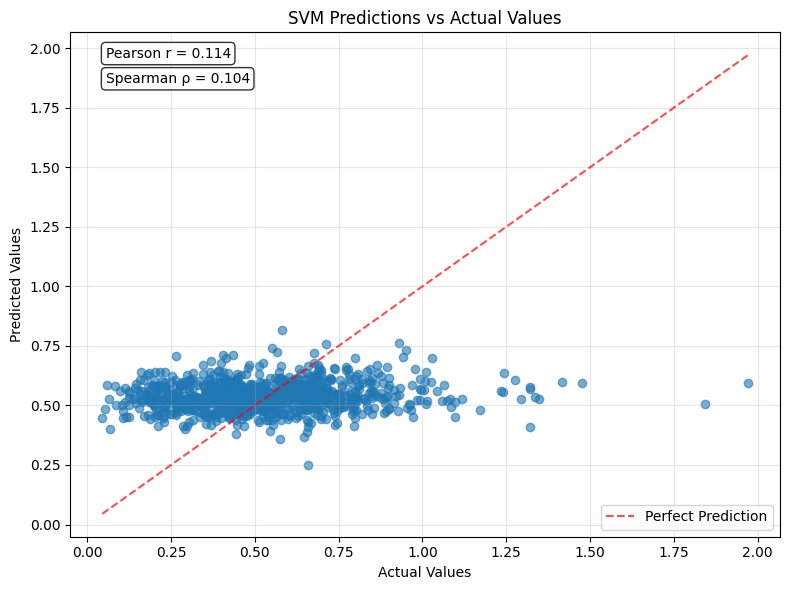

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

import matplotlib.pyplot as plt

# Read the TSV file
data = pd.read_csv('output/svm/svm_predictions.tsv', sep='\t', header=None, names=['actual', 'predicted'])

# Calculate correlation coefficients
pearson_corr, pearson_p = pearsonr(data['actual'], data['predicted'])
spearman_corr, spearman_p = spearmanr(data['actual'], data['predicted'])

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(data['actual'], data['predicted'], alpha=0.6)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVM Predictions vs Actual Values')

# Add diagonal line for perfect prediction
min_val = min(data['actual'].min(), data['predicted'].min())
max_val = max(data['actual'].max(), data['predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Perfect Prediction')

# Add correlation coefficients to the plot
plt.text(0.05, 0.95, f'Pearson r = {pearson_corr:.3f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.text(0.05, 0.90, f'Spearman ρ = {spearman_corr:.3f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()